# Tall vs Wide: The Squirrel Census

The **shape** of your data decides what you can easily do with it.

This notebook uses the real **2018 Central Park Squirrel Census** (3,023 squirrels)
to answer one simple-sounding question:

> **Which activity is most common?**

We will try to answer it *without* reshaping first, watch that get painful, and then
fix it with `melt()`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv("squirrel_census.csv")
print(df.shape)
df.head()

(3023, 31)


,x,y,unique_squirrel_id,hectare,shift,date,hectare_squirrel_number,age,primary_fur_color,highlight_fur_color,...,kuks,quaas,moans,tail_flags,tail_twitches,approaches,indifferent,runs_from,other_interactions,geocoded_column
0,-73.956134,40.794082,37F-PM-1014-03,37F,PM,10142018,3,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.9561344937861 40.7940823884086)
1,-73.968857,40.783783,21B-AM-1019-04,21B,AM,10192018,4,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.9688574691102 40.7837825208444)
2,-73.974281,40.775534,11B-PM-1014-08,11B,PM,10142018,8,NaN,Gray,NaN,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.97428114848522 40.775533619083)
3,-73.959641,40.790313,32E-PM-1017-14,32E,PM,10172018,14,Adult,Gray,NaN,...,False,False,False,False,False,False,False,True,NaN,POINT (-73.9596413903948 40.7903128889029)
4,-73.970268,40.776213,13E-AM-1017-05,13E,AM,10172018,5,Adult,Gray,Cinnamon,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.9702676472613 40.7762126854894)


## The data is WIDE

Look at how the activities are stored. Each activity gets its **own column**,
holding `True` or `False`. That is **wide** data: the variable name (`activity`)
is hiding in the **column headers**.

In [2]:
activities = ["running", "chasing", "climbing", "eating", "foraging"]

df[["unique_squirrel_id"] + activities].head()

,unique_squirrel_id,running,chasing,climbing,eating,foraging
0,37F-PM-1014-03,False,False,False,False,False
1,21B-AM-1019-04,False,False,False,False,False
2,11B-PM-1014-08,False,True,False,False,False
3,32E-PM-1017-14,False,False,False,True,True
4,13E-AM-1017-05,False,False,False,False,True


## Attempt 1: just plot it

seaborn needs **one column** to point `x` at. But "activity" is not a column,
it is five columns. The closest we can do is plot a single activity.

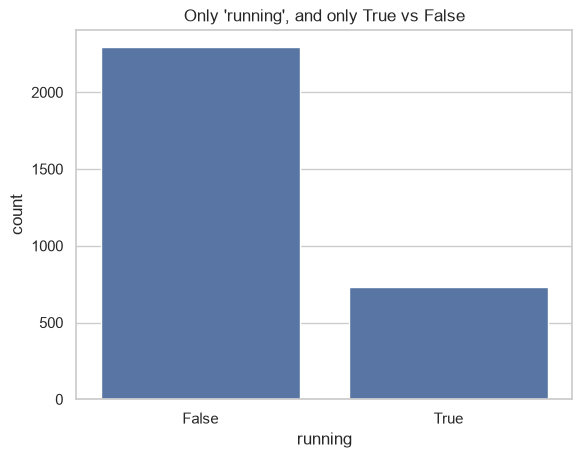

In [3]:
sns.countplot(data=df, x="running")
plt.title("Only 'running', and only True vs False")
plt.show()

That did not answer the question. It compared `True` vs `False` for **one** activity.

## Attempt 2: one chart per activity

We could make five charts. But now we are eyeballing across five y-axes,
and comparing them is awkward.

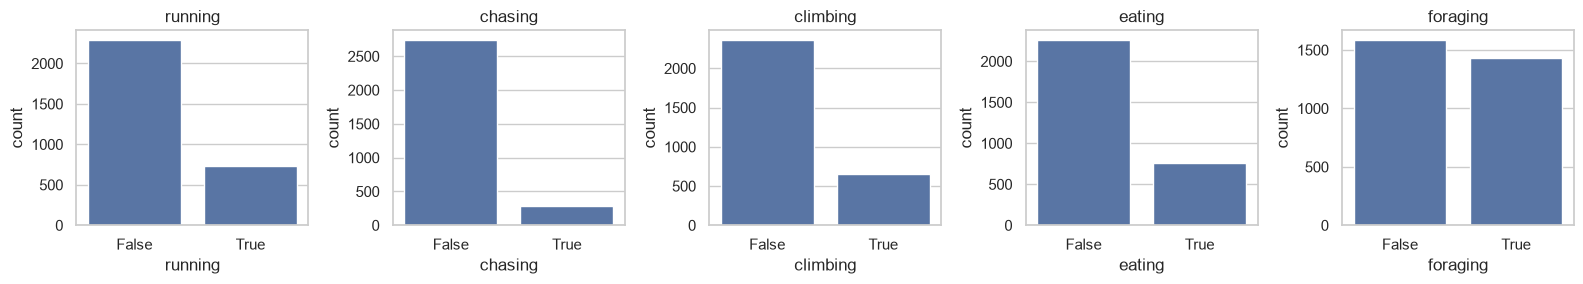

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3))

for ax, activity in zip(axes, activities):
    sns.countplot(data=df, x=activity, ax=ax)
    ax.set_title(activity)

plt.tight_layout()
plt.show()

## Attempt 3: hand-count the columns

We can sum the boolean columns ourselves. This finally gives numbers, but notice
what we gave up: we dropped out of the DataFrame and into a bare Series.

In [5]:
counts = df[activities].sum()
counts

running      730
chasing      279
climbing     658
eating       760
foraging    1435
dtype: int64

It works, but it does not compose. Try to break that down by fur color or by
shift and you are stuck: there is no `activity` column to group by. You would have
to reshape... which is the whole point.

## The real problem

`activity` is trapped in the **column headers**. seaborn (and `groupby`) want it as
**data**, in a column.

That is exactly what **`melt()`** does: it takes **wide** data and makes it **long**.
The columns melt *down* into rows.

In [6]:
long = df.melt(
    id_vars=["unique_squirrel_id", "primary_fur_color", "shift"],
    value_vars=activities,
    var_name="activity",     # the old column headers become this column
    value_name="doing_it",   # the True/False values become this column
)

print("wide:", df[activities].shape, " -> long:", long.shape)
long.head()

wide: (3023, 5)  -> long: (15115, 5)


,unique_squirrel_id,primary_fur_color,shift,activity,doing_it
0,37F-PM-1014-03,NaN,PM,running,False
1,21B-AM-1019-04,NaN,AM,running,False
2,11B-PM-1014-08,Gray,PM,running,False
3,32E-PM-1017-14,Gray,PM,running,False
4,13E-AM-1017-05,Gray,AM,running,False


3,023 squirrels x 5 activities = **15,115 rows**. Wide gained columns; long gains rows.

Now `activity` is a real column, so we can filter to the squirrels that were actually
doing each thing, and answer the question in **one call**.

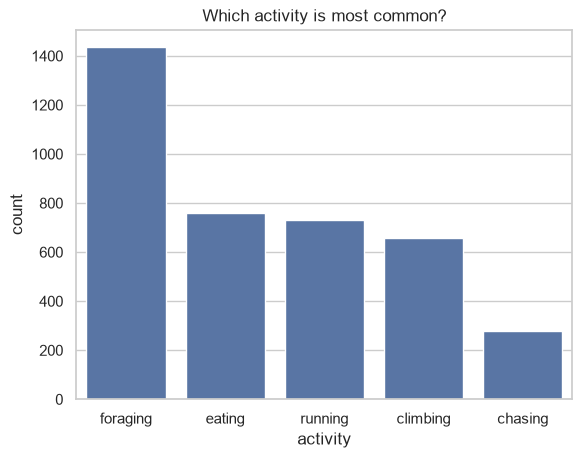

In [7]:
doing = long[long["doing_it"]]

sns.countplot(
    data=doing,
    x="activity",
    order=doing["activity"].value_counts().index,
)
plt.title("Which activity is most common?")
plt.show()

One call. All five activities, sorted. That is the entire argument for long data.

## And now `hue` just works

Because `activity` is a column, we can split by **any other column** for free.
This was impossible in wide form.

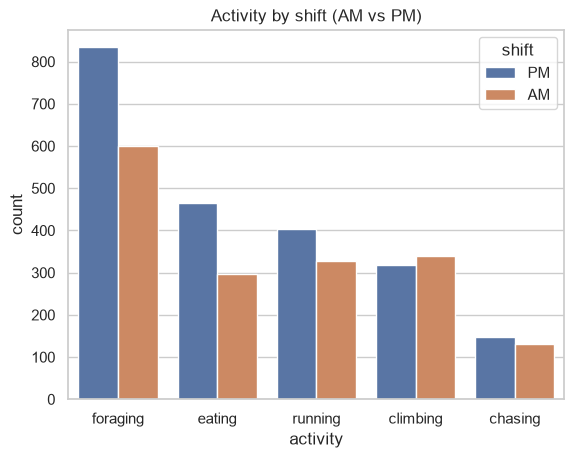

In [8]:
sns.countplot(
    data=doing,
    x="activity",
    hue="shift",
    order=doing["activity"].value_counts().index,
)
plt.title("Activity by shift (AM vs PM)")
plt.show()

## Back to WIDE for a report: `pivot_table()`

Long is for machines. **Wide is for people.** To hand someone a table they can read,
pivot it back: the rows pivot *up* into columns.

In [9]:
table = doing.pivot_table(
    index="primary_fur_color",   # becomes the rows
    columns="activity",          # its values become the new headers
    values="doing_it",
    aggfunc="sum",               # count the Trues
)
table

activity,chasing,climbing,eating,foraging,running
primary_fur_color,,,,,
Black,7,25,24,43,26
Cinnamon,30,82,111,203,103
Gray,238,533,619,1183,597


## Takeaway

- **`melt()`**: wide -> long. The columns melt *down* into rows.
- **`pivot_table()`**: long -> wide. The rows pivot *up* into columns.
- **seaborn wants long.** Reports want wide.

If plotting feels impossible, check the shape of your data before you blame the chart.